# Python for Data Science Project
## Dataset: YouTube Comments Analysis

### 1. Data Preparation

In [26]:
# --- Cell 2: Import Libraries & Load Unified Dataset ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Ensure 'charts' directory exists
charts_dir = Path("charts")
charts_dir.mkdir(exist_ok=True)

# Set global visualization style
sns.set_theme(style="whitegrid")

# Load the unified dataset containing sentiment labels
input_file = 'youtube_comments_with_sentiment.csv'

if not os.path.exists(input_file):
    print(f"\nERROR: The file '{input_file}' is missing!")
    raise SystemExit

df = pd.read_csv(input_file)

# Basic data formatting
df['word_count'] = pd.to_numeric(df['word_count'], errors='coerce')
df['like_count_numeric'] = pd.to_numeric(df['like_count_numeric'], errors='coerce')

print(f"Successfully loaded '{input_file}'. Total records: {len(df)}")
df.head()

Successfully loaded 'youtube_comments_with_sentiment.csv'. Total records: 1572


,comment_id,comment,author,like_count,time_text,reply,clean_comment,like_count_numeric,word_count,character_count,comment_type,sentiment
0,Ugy1UF-xl8nO0c6-K_R4AaABAg,Mother earth can live with or without the huma...,@nikakiskainourgios2227,2.7K,2 bulan lalu (diedit),False,Mother earth can live with or without the huma...,2700,10,55,Top-level,Positive
1,UgxoF6T9rsEzxfgIyX14AaABAg,El Niño growing to El Hombre,@v8van,1.8K,2 bulan lalu,False,El Niño growing to El Hombre,1800,6,28,Top-level,Neutral
2,Ugxgdko85P_MhG4gMSZ4AaABAg,why the video looks like a 90s news tv?,@theshuriken,566,2 bulan lalu,False,why the video looks like a 90s news tv?,566,9,39,Top-level,Neutral
3,Ugz3jagskTxouJyuo_F4AaABAg,Everybody ought to start panicking because it ...,@lahayestudiofrqc8708,22,2 bulan lalu,False,Everybody ought to start panicking because it ...,22,9,58,Top-level,Neutral
4,Ugw7t7XBAr39u7rTn354AaABAg,"Everyone’s busy arguing, meanwhile a massive E...",@enfriendumachan,59,2 bulan lalu,False,"Everyone’s busy arguing, meanwhile a massive E...",59,14,87,Top-level,Positive


## Research Question 1 (RQ1)
**Research Question:** Is there a correlation between the word count of a comment and the number of likes it receives?

### Statistical Analysis & Visualization Pipeline
This section investigates the statistical relationship between the length of a comment (`word_count`) and user engagement (`like_count_numeric`). 
The analysis pipeline includes:
* Data preprocessing and outlier removal using the Interquartile Range (IQR) technique.
* Descriptive statistics detailing the distributions of word counts and like counts.
* Calculation of both Pearson and Spearman correlation coefficients to measure linear and monotonic dependencies.
* Generation of visual distributions and scatter plots stored in the `charts/` directory.

RQ1 ANALYSIS

Research Question:
Is there a correlation between the word count of a comment and the number of likes it receives?

Loading dataset:
c:\Users\USER\OneDrive - Southern University College\Documents\Degree of Software Engineering\26 B BoSE\Python\BTPR3203_Project\youtube_comments_with_sentiment.csv

Dataset loaded successfully.
Records: 1572

DATA PREPARATION
Records before preparation : 1572
Removed invalid records     : 0
Records used for analysis   : 1572

DESCRIPTIVE STATISTICS

Word Count Statistics:
count    1572.000000
mean       21.112595
std        41.560958
min         1.000000
25%         6.000000
50%        12.000000
75%        22.250000
max      1018.000000
Name: word_count, dtype: float64

Like Count Statistics:
count    1572.000000
mean        7.815522
std        92.751218
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max      2700.000000
Name: like_count_numeric, dtype: float64

ZERO-LIKE COMMENTS
Comments with 0 likes : 

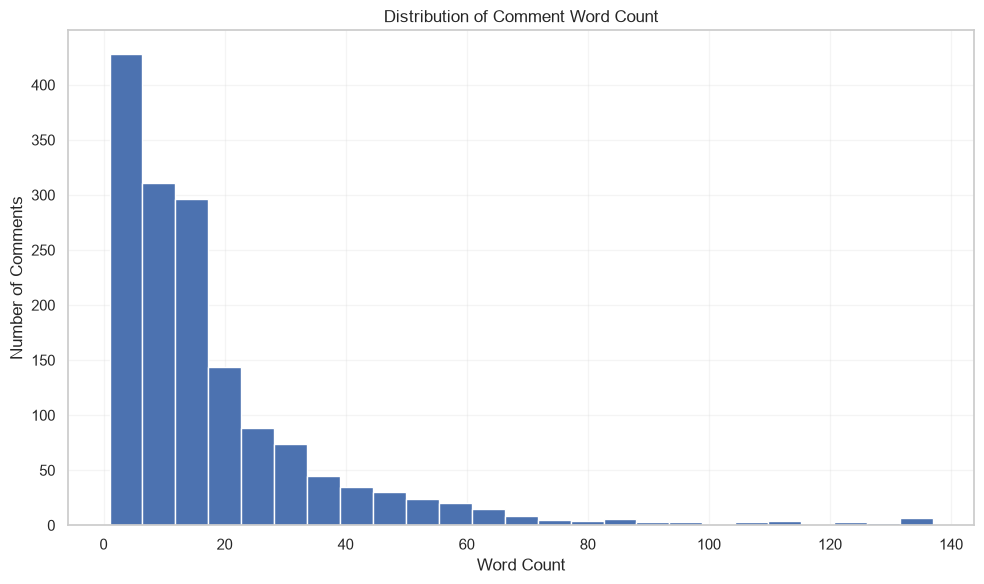

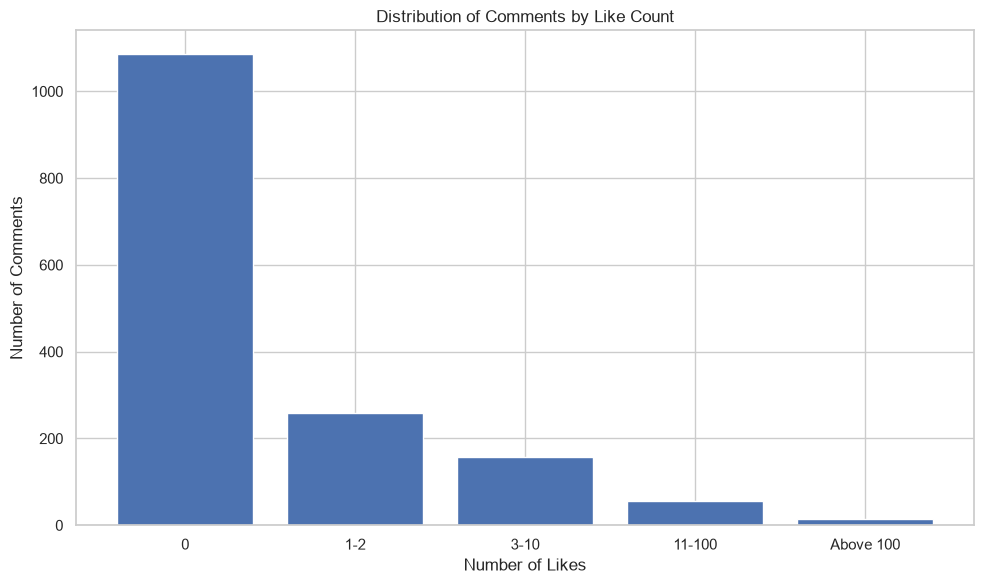

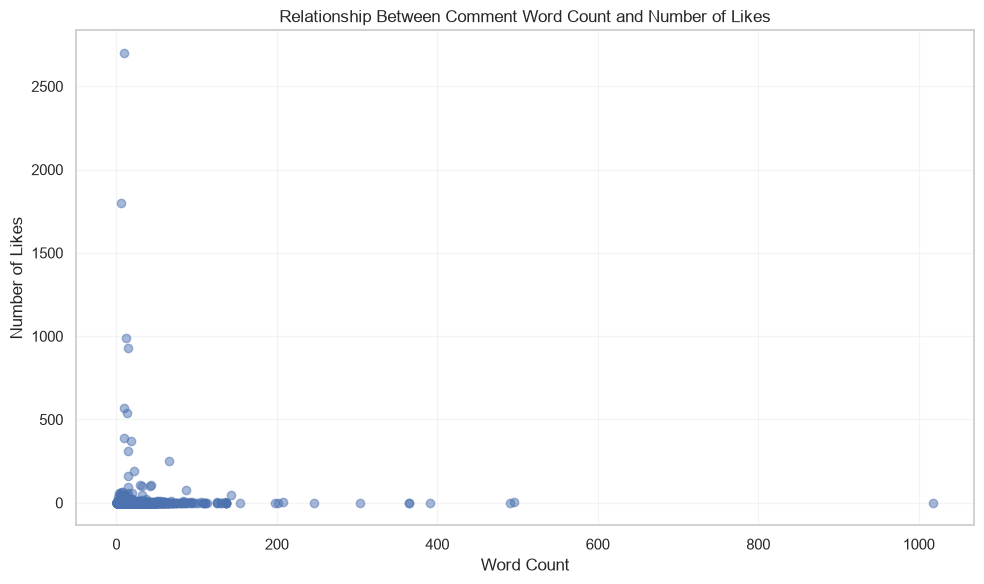

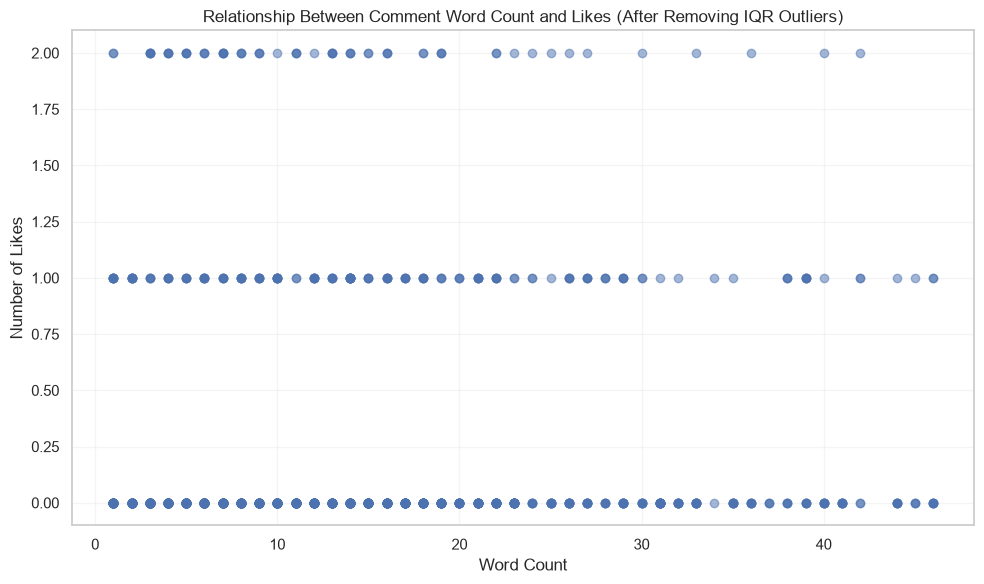


RQ1 ANALYSIS COMPLETE


In [27]:
# --- RQ1 Full Analysis Script ---
import matplotlib.pyplot as plt
from pathlib import Path

# 1. FILE PATHS
base_dir = Path.cwd()
input_file = base_dir / "youtube_comments_with_sentiment.csv"
word_distribution_chart = figure_dir / "rq1_wordcount_distribution.png"
like_group_chart = figure_dir / "rq1_likecount_groups.png"
output_chart = figure_dir / "rq1_wordcount_likes.png"
filtered_chart = figure_dir / "rq1_wordcount_likes_filtered.png"
output_summary = base_dir / "rq1_summary.csv"

# 2. LOAD DATA
print("=" * 70)
print("RQ1 ANALYSIS")
print("=" * 70)
print("\nResearch Question:")
print("Is there a correlation between the word count of a comment and the number of likes it receives?")
print("\nLoading dataset:")
print(input_file)

df_rq1 = pd.read_csv(input_file)

print("\nDataset loaded successfully.")
print(f"Records: {len(df_rq1)}")

# 3. CHECK REQUIRED COLUMNS
required_columns = ["word_count", "like_count_numeric"]
missing_columns = [column for column in required_columns if column not in df_rq1.columns]

if missing_columns:
    print("\nERROR:")
    print("The following required columns are missing:")
    print(missing_columns)
    raise SystemExit

# 4. REMOVE INVALID VALUES
analysis_df = df_rq1[["comment", "word_count", "like_count_numeric"]].copy()
analysis_df["word_count"] = pd.to_numeric(analysis_df["word_count"], errors="coerce")
analysis_df["like_count_numeric"] = pd.to_numeric(analysis_df["like_count_numeric"], errors="coerce")

before_cleaning = len(analysis_df)
analysis_df = analysis_df.dropna(subset=["word_count", "like_count_numeric"])
analysis_df = analysis_df[analysis_df["word_count"] > 0]
after_cleaning = len(analysis_df)
removed = before_cleaning - after_cleaning

print("\n" + "=" * 70)
print("DATA PREPARATION")
print("=" * 70)
print(f"Records before preparation : {before_cleaning}")
print(f"Removed invalid records     : {removed}")
print(f"Records used for analysis   : {after_cleaning}")

# 5. DESCRIPTIVE STATISTICS
word_stats = analysis_df["word_count"].describe()
like_stats = analysis_df["like_count_numeric"].describe()

print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)
print("\nWord Count Statistics:")
print(word_stats)
print("\nLike Count Statistics:")
print(like_stats)

# 6. ZERO-LIKE COMMENTS
zero_like_count = (analysis_df["like_count_numeric"] == 0).sum()
zero_like_percentage = (zero_like_count / len(analysis_df)) * 100

print("\n" + "=" * 70)
print("ZERO-LIKE COMMENTS")
print("=" * 70)
print(f"Comments with 0 likes : {zero_like_count}")
print(f"Percentage             : {zero_like_percentage:.2f}%")

# 7. PEARSON CORRELATION
pearson_corr = analysis_df["word_count"].corr(analysis_df["like_count_numeric"], method="pearson")

print("\n" + "=" * 70)
print("PEARSON CORRELATION")
print("=" * 70)
print(f"Pearson correlation coefficient: {pearson_corr:.4f}")

# 8. SPEARMAN CORRELATION
spearman_corr = analysis_df["word_count"].corr(analysis_df["like_count_numeric"], method="spearman")

print("\n" + "=" * 70)
print("SPEARMAN CORRELATION")
print("=" * 70)
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")

# 9. INTERPRET CORRELATION
def correlation_strength(value):
    value = abs(value)
    if value < 0.10:
        return "very weak"
    elif value < 0.30:
        return "weak"
    elif value < 0.50:
        return "moderate"
    elif value < 0.70:
        return "strong"
    else:
        return "very strong"

def correlation_direction(value):
    if value > 0:
        return "positive"
    elif value < 0:
        return "negative"
    else:
        return "no"

pearson_strength = correlation_strength(pearson_corr)
pearson_direction = correlation_direction(pearson_corr)
spearman_strength = correlation_strength(spearman_corr)
spearman_direction = correlation_direction(spearman_corr)

print("\n" + "=" * 70)
print("CORRELATION INTERPRETATION")
print("=" * 70)
print(f"Pearson indicates a {pearson_strength} {pearson_direction} relationship.")
print(f"Spearman indicates a {spearman_strength} {spearman_direction} relationship.")

# 10. TOP 10 MOST-LIKED COMMENTS
top_comments = analysis_df.nlargest(10, "like_count_numeric")[["comment", "word_count", "like_count_numeric"]]

print("\n" + "=" * 70)
print("TOP 10 MOST-LIKED COMMENTS")
print("=" * 70)
print(top_comments.to_string(index=False))

# 11. OUTLIER ANALYSIS
word_q1 = analysis_df["word_count"].quantile(0.25)
word_q3 = analysis_df["word_count"].quantile(0.75)
word_iqr = word_q3 - word_q1
word_upper_limit = word_q3 + (1.5 * word_iqr)

like_q1 = analysis_df["like_count_numeric"].quantile(0.25)
like_q3 = analysis_df["like_count_numeric"].quantile(0.75)
like_iqr = like_q3 - like_q1
like_upper_limit = like_q3 + (1.5 * like_iqr)

word_outliers = analysis_df[analysis_df["word_count"] > word_upper_limit]
like_outliers = analysis_df[analysis_df["like_count_numeric"] > like_upper_limit]

print("\n" + "=" * 70)
print("OUTLIER ANALYSIS")
print("=" * 70)
print(f"Word count upper outlier limit : {word_upper_limit:.2f}")
print(f"Word count outliers            : {len(word_outliers)}")
print(f"Like count upper outlier limit : {like_upper_limit:.2f}")
print(f"Like count outliers            : {len(like_outliers)}")

# 12. CORRELATION AFTER REMOVING IQR OUTLIERS
filtered_df = analysis_df[(analysis_df["word_count"] <= word_upper_limit) & (analysis_df["like_count_numeric"] <= like_upper_limit)].copy()
pearson_filtered = filtered_df["word_count"].corr(filtered_df["like_count_numeric"], method="pearson")
spearman_filtered = filtered_df["word_count"].corr(filtered_df["like_count_numeric"], method="spearman")

print("\n" + "=" * 70)
print("CORRELATION AFTER REMOVING IQR OUTLIERS")
print("=" * 70)
print(f"Remaining records       : {len(filtered_df)}")
print(f"Pearson correlation     : {pearson_filtered:.4f}")
print(f"Spearman correlation    : {spearman_filtered:.4f}")

# 13. WORD COUNT DISTRIBUTION
word_display_limit = analysis_df["word_count"].quantile(0.99)
word_display_df = analysis_df[analysis_df["word_count"] <= word_display_limit]

plt.figure(figsize=(10, 6))
plt.hist(word_display_df["word_count"], bins=25)
plt.xlabel("Word Count")
plt.ylabel("Number of Comments")
plt.title("Distribution of Comment Word Count")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(word_distribution_chart, dpi=300, bbox_inches="tight")
plt.show()

# 14. LIKE COUNT GROUPS
analysis_df["like_group"] = pd.cut(analysis_df["like_count_numeric"], bins=[-1, 0, 2, 10, 100, float("inf")], labels=["0", "1-2", "3-10", "11-100", "Above 100"])
like_group_counts = analysis_df["like_group"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(like_group_counts.index.astype(str), like_group_counts.values)
plt.xlabel("Number of Likes")
plt.ylabel("Number of Comments")
plt.title("Distribution of Comments by Like Count")
plt.tight_layout()
plt.savefig(like_group_chart, dpi=300, bbox_inches="tight")
plt.show()

# 15. SCATTER PLOT
plt.figure(figsize=(10, 6))
plt.scatter(analysis_df["word_count"], analysis_df["like_count_numeric"], alpha=0.5)
plt.xlabel("Word Count")
plt.ylabel("Number of Likes")
plt.title("Relationship Between Comment Word Count and Number of Likes")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(output_chart, dpi=300, bbox_inches="tight")
plt.show()

# 16. FILTERED SCATTER PLOT
plt.figure(figsize=(10, 6))
plt.scatter(filtered_df["word_count"], filtered_df["like_count_numeric"], alpha=0.5)
plt.xlabel("Word Count")
plt.ylabel("Number of Likes")
plt.title("Relationship Between Comment Word Count and Likes (After Removing IQR Outliers)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(filtered_chart, dpi=300, bbox_inches="tight")
plt.show()

# 17. SAVE SUMMARY OUTPUT
summary = pd.DataFrame({
    "Metric": [
        "Total records analysed", "Mean word count", "Median word count", "Maximum word count",
        "Mean like count", "Median like count", "Maximum like count", "Zero-like comments",
        "Zero-like percentage", "Pearson correlation", "Spearman correlation", "Word count outliers",
        "Like count outliers", "Filtered records", "Filtered Pearson correlation", "Filtered Spearman correlation"
    ],
    "Value": [
        len(analysis_df), analysis_df["word_count"].mean(), analysis_df["word_count"].median(), analysis_df["word_count"].max(),
        analysis_df["like_count_numeric"].mean(), analysis_df["like_count_numeric"].median(), analysis_df["like_count_numeric"].max(),
        zero_like_count, zero_like_percentage, pearson_corr, spearman_corr, len(word_outliers), len(like_outliers),
        len(filtered_df), pearson_filtered, spearman_filtered
    ]
})

summary.to_csv(output_summary, index=False, encoding="utf-8-sig")

print("\n" + "=" * 70)
print("RQ1 ANALYSIS COMPLETE")
print("=" * 70)

## Research Question 2 (RQ2)
**Research Question:** Do top-level comments receive more likes than replies?

### Engagement Comparison Pipeline
This section evaluates whether top-level comments generate higher user engagement compared to nested replies. 
The analysis pipeline includes:
* Aggregating engagement metrics (mean, median, and maximum likes) grouped by comment type.
* Comparative bar plotting of mean versus median values to assess skewness.
* Boxplot visualizations showcasing the distribution of likes across top-level comments and replies.
* Proportion analysis examining the ratio of zero-like comments versus comments with active engagement.

RQ2 ANALYSIS: Top-level Comments vs. Replies Engagement

--- Engagement Statistics by Comment Type ---
Comment Type  count      mean  median  max
   Top-level    982 10.877800     0.0 2700
       Reply    590  2.718644     1.0   59

RQ2 summary statistics exported successfully to 'rq2_summary.csv'.


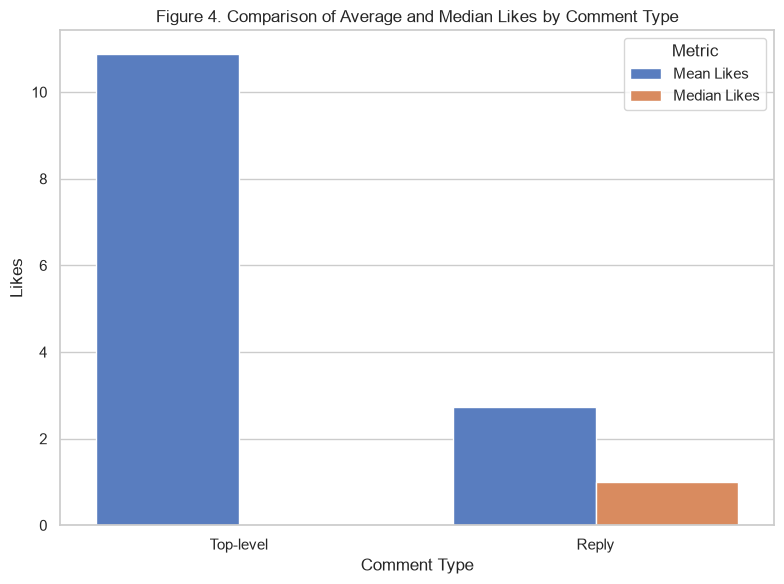

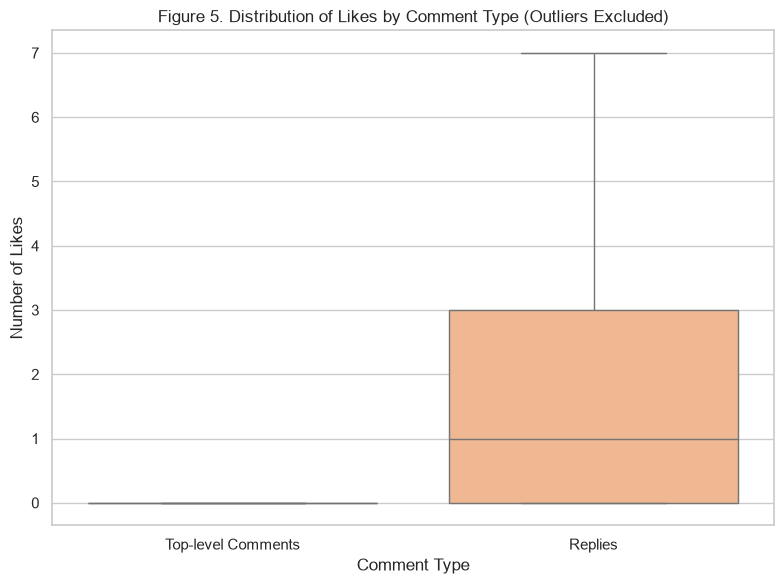

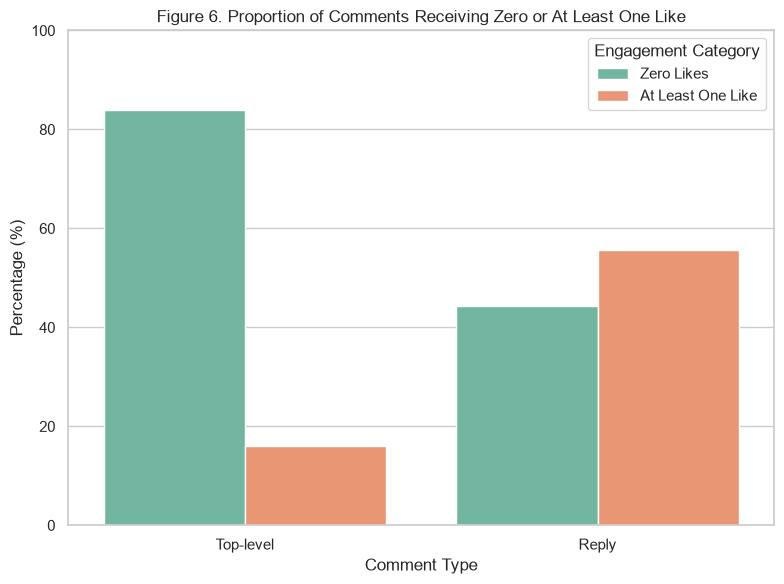


RQ2 ANALYSIS COMPLETE (Charts saved in 'figure/', summary CSV saved)


In [32]:
# --- RQ2 Full Analysis Script ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("RQ2 ANALYSIS: Top-level Comments vs. Replies Engagement")
print("=" * 70)

# Use global df loaded from 'youtube_comments_with_sentiment.csv'
df_rq2 = df.copy()

# 1. Statistical Summary by Comment Type
stats_summary = df_rq2.groupby('reply')['like_count_numeric'].agg(['count', 'mean', 'median', 'max']).reset_index()
stats_summary['Comment Type'] = stats_summary['reply'].map({False: 'Top-level', True: 'Reply'})

print("\n--- Engagement Statistics by Comment Type ---")
print(stats_summary[['Comment Type', 'count', 'mean', 'median', 'max']].to_string(index=False))

# 2. Calculate Proportions of Zero-Like vs Active Comments
zero_top = (df_rq2[(df_rq2['reply'] == False) & (df_rq2['like_count_numeric'] == 0)].shape[0] / df_rq2[df_rq2['reply'] == False].shape[0]) * 100
active_top = 100 - zero_top
zero_reply = (df_rq2[(df_rq2['reply'] == True) & (df_rq2['like_count_numeric'] == 0)].shape[0] / df_rq2[df_rq2['reply'] == True].shape[0]) * 100
active_reply = 100 - zero_reply

# 3. Create and Save RQ2 Summary CSV Output
rq2_summary_df = pd.DataFrame({
    "Comment Type": ["Top-level", "Reply"],
    "Total Count": [
        df_rq2[df_rq2['reply'] == False].shape[0],
        df_rq2[df_rq2['reply'] == True].shape[0]
    ],
    "Mean Likes": [
        df_rq2[df_rq2['reply'] == False]['like_count_numeric'].mean(),
        df_rq2[df_rq2['reply'] == True]['like_count_numeric'].mean()
    ],
    "Median Likes": [
        df_rq2[df_rq2['reply'] == False]['like_count_numeric'].median(),
        df_rq2[df_rq2['reply'] == True]['like_count_numeric'].median()
    ],
    "Max Likes": [
        df_rq2[df_rq2['reply'] == False]['like_count_numeric'].max(),
        df_rq2[df_rq2['reply'] == True]['like_count_numeric'].max()
    ],
    "Zero-Like Percentage (%)": [zero_top, zero_reply],
    "Active (>=1 Like) Percentage (%)": [active_top, active_reply]
})

rq2_summary_df.to_csv('rq2_summary.csv', index=False, encoding='utf-8-sig')
print("\nRQ2 summary statistics exported successfully to 'rq2_summary.csv'.")

# --- VISUALIZATIONS ---

# Figure 4: Mean and Median Comparison Barplot
fig, ax = plt.subplots(figsize=(8, 6))
stats_df = pd.DataFrame({
    'Metric': ['Mean Likes', 'Median Likes', 'Mean Likes', 'Median Likes'],
    'Value': [
        df_rq2[df_rq2['reply'] == False]['like_count_numeric'].mean(),
        df_rq2[df_rq2['reply'] == False]['like_count_numeric'].median(),
        df_rq2[df_rq2['reply'] == True]['like_count_numeric'].mean(),
        df_rq2[df_rq2['reply'] == True]['like_count_numeric'].median()
    ],
    'Comment Type': ['Top-level', 'Top-level', 'Reply', 'Reply']
})
sns.barplot(data=stats_df, x='Comment Type', y='Value', hue='Metric', palette='muted', ax=ax)
ax.set_title('Figure 4. Comparison of Average and Median Likes by Comment Type')
ax.set_ylabel('Likes')
plt.tight_layout()
plt.savefig(figure_dir / 'rq2_mean_median.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 5: Like Distribution Boxplot (Outliers Excluded)
plt.figure(figsize=(8, 6))
sns.boxplot(x='reply', y='like_count_numeric', data=df_rq2, order=[False, True], showfliers=False, hue='reply', palette='pastel', legend=False)
plt.xticks([0, 1], ['Top-level Comments', 'Replies'])
plt.title('Figure 5. Distribution of Likes by Comment Type (Outliers Excluded)')
plt.xlabel('Comment Type')
plt.ylabel('Number of Likes')
plt.tight_layout()
plt.savefig(figure_dir / 'rq2_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 6: Zero-Like vs At Least One Like Proportions Barplot
prop_df = pd.DataFrame({
    'Comment Type': ['Top-level', 'Top-level', 'Reply', 'Reply'],
    'Engagement Category': ['Zero Likes', 'At Least One Like', 'Zero Likes', 'At Least One Like'],
    'Percentage': [zero_top, active_top, zero_reply, active_reply]
})
plt.figure(figsize=(8, 6))
sns.barplot(data=prop_df, x='Comment Type', y='Percentage', hue='Engagement Category', palette='Set2')
plt.title('Figure 6. Proportion of Comments Receiving Zero or At Least One Like')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(figure_dir / 'rq2_proportions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("RQ2 ANALYSIS COMPLETE (Charts saved in 'figure/', summary CSV saved)")
print("=" * 70)

## Research Question 3 (RQ3)
**Research Question:** How accurately can machine learning classify YouTube comments into Positive, Negative, and Neutral sentiment categories?

### Machine Learning Classification Pipeline
This section implements an automated text classification pipeline to predict comment sentiments. 
The modeling pipeline includes:
* Text feature extraction using TF-IDF Vectorization with n-gram and stop-word filtering.
* Supervised learning via a Logistic Regression classifier with a stratified 80-20 train-test split.
* Comprehensive performance evaluation utilizing accuracy scores, classification reports (precision, recall, F1-score), and a confusion matrix heatmap.
* Feature importance interpretation highlighting the top 10 coefficients driving positive and negative sentiment predictions.

RQ3 ANALYSIS: Machine Learning Sentiment Classification

--- RQ3: Loading Dataset ---
Dataset loaded successfully. Total comments to classify: 1572

--- RQ3: Executing Feature Extraction & Model Training ---
Logistic Regression Model training complete.

--- RQ3: Evaluation & Graph 3.1 ---
Overall Model Accuracy: 63.81%



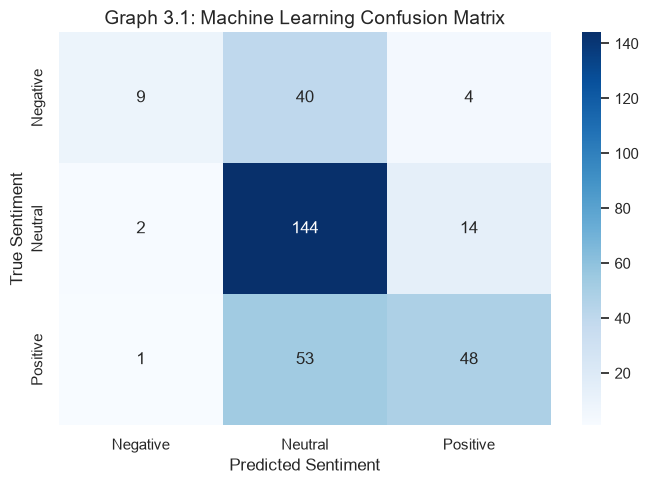


--- RQ3: Generating Graph 3.2 ---


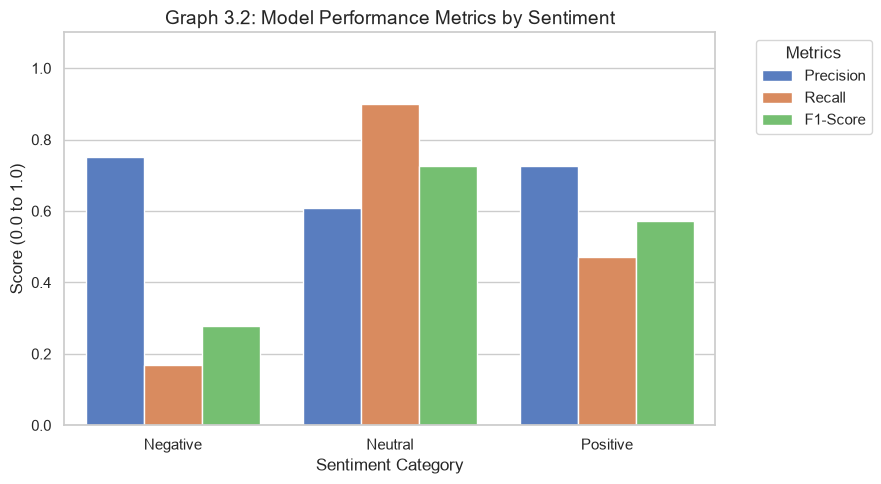


--- RQ3: Generating Graph 3.3 ---


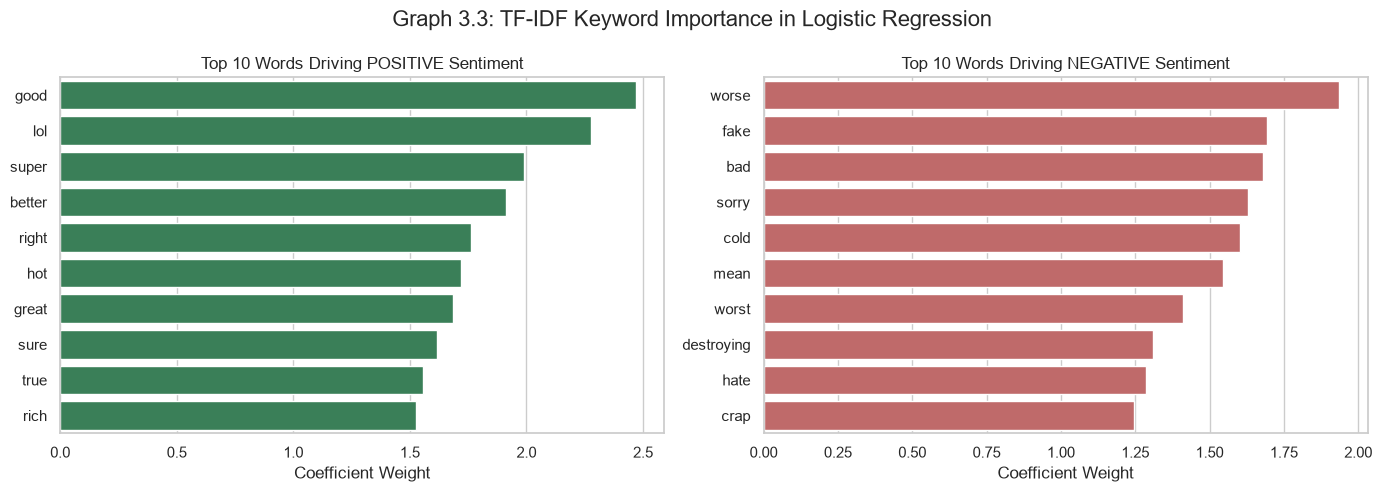


--- RQ3: Exporting Final Predictions ---
Processing complete. Saved 'rq3_final_ml_predictions.csv'.

RQ3 ANALYSIS COMPLETE (Charts saved in 'figure/' folder)


In [29]:
# --- RQ3 Full Analysis Script ---
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=" * 70)
print("RQ3 ANALYSIS: Machine Learning Sentiment Classification")
print("=" * 70)

print("\n--- RQ3: Loading Dataset ---")
df_rq3 = df.copy()
df_rq3 = df_rq3.dropna(subset=['clean_comment', 'sentiment'])

# Define features (X) and target (y)
X = df_rq3['clean_comment']
y = df_rq3['sentiment']

print(f"Dataset loaded successfully. Total comments to classify: {len(df_rq3)}")

print("\n--- RQ3: Executing Feature Extraction & Model Training ---")

# 1. Stratified split to maintain class balance (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. TF-IDF Vectorization (Extracting Text to Numbers)
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 3. Logistic Regression Model Initialization and Training
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression Model training complete.")

print("\n--- RQ3: Evaluation & Graph 3.1 ---")

# Make predictions
y_pred = lr_model.predict(X_test_tfidf)

# Calculate and print Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n")

# Graph 3.1: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Neutral', 'Positive'], 
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Graph 3.1: Machine Learning Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.tight_layout()
plt.savefig(figure_dir / 'rq3_graph1_confusion_matrix.png', dpi=300)
plt.show()

print("\n--- RQ3: Generating Graph 3.2 ---")

# Extracting metrics for the bar chart
report = classification_report(y_test, y_pred, output_dict=True)
categories = ['Negative', 'Neutral', 'Positive']

metrics_df = pd.DataFrame({
    'Category': categories,
    'Precision': [report[cat]['precision'] for cat in categories],
    'Recall': [report[cat]['recall'] for cat in categories],
    'F1-Score': [report[cat]['f1-score'] for cat in categories]
})

# Melt DataFrame for easier plotting with Seaborn
metrics_melted = metrics_df.melt(id_vars='Category', var_name='Metric', value_name='Score')

# Graph 3.2: Grouped Bar Chart
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_melted, x='Category', y='Score', hue='Metric', palette='muted')
plt.title('Graph 3.2: Model Performance Metrics by Sentiment', fontsize=14)
plt.ylabel('Score (0.0 to 1.0)')
plt.xlabel('Sentiment Category')
plt.ylim(0, 1.1)
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(figure_dir / 'rq3_graph2_metrics_bar.png', dpi=300)
plt.show()

print("\n--- RQ3: Generating Graph 3.3 ---")

# Get feature names (words) and model coefficients
feature_names = np.array(vectorizer.get_feature_names_out())

# Extract coefficients for Negative and Positive classes
classes = lr_model.classes_
neg_index = np.where(classes == 'Negative')[0][0]
pos_index = np.where(classes == 'Positive')[0][0]

negative_coefs = lr_model.coef_[neg_index] 
positive_coefs = lr_model.coef_[pos_index]

# Identify the Top 10 words
top_negative_indices = negative_coefs.argsort()[-10:][::-1]
top_positive_indices = positive_coefs.argsort()[-10:][::-1]

top_neg_words = feature_names[top_negative_indices]
top_neg_weights = negative_coefs[top_negative_indices]

top_pos_words = feature_names[top_positive_indices]
top_pos_weights = positive_coefs[top_positive_indices]

# Graph 3.3: Dual Horizontal Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=top_pos_weights, y=top_pos_words, ax=axes[0], color='seagreen')
axes[0].set_title('Top 10 Words Driving POSITIVE Sentiment')
axes[0].set_xlabel('Coefficient Weight')

sns.barplot(x=top_neg_weights, y=top_neg_words, ax=axes[1], color='indianred')
axes[1].set_title('Top 10 Words Driving NEGATIVE Sentiment')
axes[1].set_xlabel('Coefficient Weight')

plt.suptitle('Graph 3.3: TF-IDF Keyword Importance in Logistic Regression', fontsize=16)
plt.tight_layout()
plt.savefig(figure_dir / 'rq3_graph3_feature_weights.png', dpi=300)
plt.show()

print("\n--- RQ3: Exporting Final Predictions ---")

# Create a DataFrame with the test results
output_df = pd.DataFrame({
    'Clean_Comment': X_test, 
    'True_Sentiment': y_test, 
    'Predicted_Sentiment': y_pred
})

output_df.to_csv('rq3_final_ml_predictions.csv', index=False)
print("Processing complete. Saved 'rq3_final_ml_predictions.csv'.")
print("\n" + "=" * 70)
print("RQ3 ANALYSIS COMPLETE (Charts saved in 'figure/' folder)")
print("=" * 70)